# Melbourne_Analysis

## Imports

In [ ]:
# ============================================================
# MELBOURNE HOUSING DATASET — EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from scipy.stats.mstats import winsorize

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


## Load the data

In [ ]:
# Data loaded from Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Update the path to match where your file is in Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/Melbourne_analysis/assessment_melb.csv'


In [ ]:
df = pd.read_csv(file_path)

print(f"Dataset Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
df.head()

Dataset Shape  : 13,580 rows × 21 columns
Memory Usage   : 6820.4 KB



,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,42707,2.50,3067,2,1,1.00,202,NaN,NaN,Yarra,-37.80,145.00,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,42404,2.50,3067,2,1,0.00,156,79.00,1900.00,Yarra,-37.81,144.99,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,42798,2.50,3067,3,2,0.00,134,150.00,1900.00,Yarra,-37.81,144.99,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,42798,2.50,3067,3,2,1.00,94,NaN,NaN,Yarra,-37.80,145.00,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,42525,2.50,3067,3,1,2.00,120,142.00,2014.00,Yarra,-37.81,144.99,Northern Metropolitan,4019


## Fix the Date Column

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], unit='D', origin='1899-12-30')

# Extract useful time components
df['Sale_Year']      = df['Date'].dt.year
df['Sale_Month']     = df['Date'].dt.month
df['Sale_MonthName'] = df['Date'].dt.strftime('%b')
df['Sale_YearMonth'] = df['Date'].dt.to_period('M').astype(str)

print("Date range:", df['Date'].min().date(), "→", df['Date'].max().date())
df[['Date','Sale_Year','Sale_Month','Sale_MonthName','Sale_YearMonth']].head(3)

Date range: 2016-01-28 → 2017-09-23


,Date,Sale_Year,Sale_Month,Sale_MonthName,Sale_YearMonth
0,2016-12-03,2016,12,Dec,2016-12
1,2016-02-04,2016,2,Feb,2016-02
2,2017-03-04,2017,3,Mar,2017-03


## Null Values Handling

In [ ]:
null_audit = pd.DataFrame({
    'Null_Count'  : df.isnull().sum(),
    'Null_Pct'    : round(df.isnull().mean() * 100, 2),
    'Dtype'       : df.dtypes
}).query('Null_Count > 0').sort_values('Null_Pct', ascending=False)

print("=" * 45)
print("       NULL AUDIT — Melbourne Housing")
print("=" * 45)
print(null_audit.to_string())
print("=" * 45)
print(f"\nTotal rows           : {len(df):,}")
print(f"Columns with nulls   : {len(null_audit)}")
print(f"Completely clean cols: {df.shape[1] - len(null_audit)}")

       NULL AUDIT — Melbourne Housing
              Null_Count  Null_Pct    Dtype
BuildingArea        6450     47.50  float64
YearBuilt           5375     39.58  float64
CouncilArea         1369     10.08   object
Car                   62      0.46  float64

Total rows           : 13,580
Columns with nulls   : 4
Completely clean cols: 21


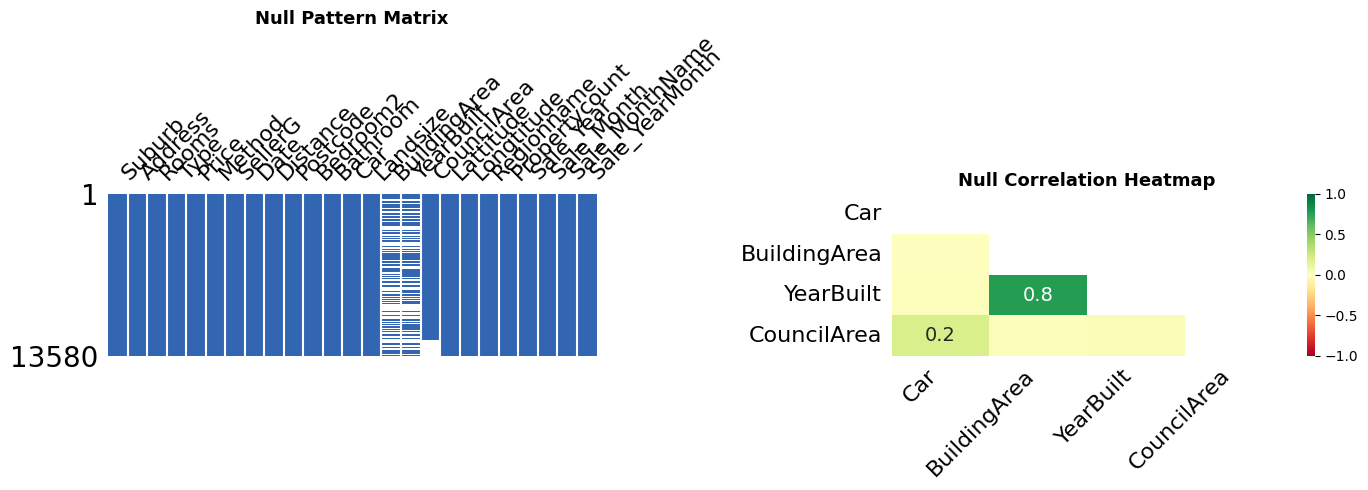

✓ Saved: null_audit_visual.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrix — shows WHERE nulls fall across rows
msno.matrix(df, ax=axes[0], sparkline=False,
            color=(0.2, 0.4, 0.7))
axes[0].set_title('Null Pattern Matrix', fontsize=13, fontweight='bold')

# Heatmap — shows which columns have CORRELATED nulls
msno.heatmap(df, ax=axes[1], cmap='RdYlGn')
axes[1].set_title('Null Correlation Heatmap', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('null_audit_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: null_audit_visual.png")

 * **Building Area** and **YearBuilt** will show a strong positive correlation.
 * Properties missing one tend to miss the other. This tells you they are **MNAR (Missing Not At Random)** — likely older or incomplete records — which justifies grouped median imputation rather than simple global median.


## Dtype Audit

In [ ]:
print("DATA TYPE AUDIT")
print("-" * 35)

for col in df.columns:
    null_flag = " ← HAS NULLS" if df[col].isnull().any() else ""
    print(f"  {col:<20} {str(df[col].dtype):<12}{null_flag}")

DATA TYPE AUDIT
-----------------------------------
  Suburb               object      
  Address              object      
  Rooms                int64       
  Type                 object      
  Price                int64       
  Method               object      
  SellerG              object      
  Date                 datetime64[ns]
  Distance             float64     
  Postcode             int64       
  Bedroom2             int64       
  Bathroom             int64       
  Car                  float64      ← HAS NULLS
  Landsize             int64       
  BuildingArea         float64      ← HAS NULLS
  YearBuilt            float64      ← HAS NULLS
  CouncilArea          object       ← HAS NULLS
  Lattitude            float64     
  Longtitude           float64     
  Regionname           object      
  Propertycount        int64       
  Sale_Year            int32       
  Sale_Month           int32       
  Sale_MonthName       object      
  Sale_YearMonth       object     

In [ ]:
# ============================================================
# DTYPE CLEANUP
# ============================================================

# ── 1. Categorical columns ─────
cat_cols = ['Type', 'Method', 'Regionname', 'CouncilArea',
            'Sale_MonthName', 'Sale_YearMonth']
for col in cat_cols:
    df[col] = df[col].astype('category')

# ── 2. True integer columns ──────────
int_cols = ['Rooms', 'Bedroom2', 'Bathroom', 'Postcode',
            'Propertycount', 'Sale_Year', 'Sale_Month']
for col in int_cols:
    df[col] = df[col].astype('int64')

# ── 3. Float columns  ───────────────────
float_cols = ['Price', 'Distance', 'Landsize',
              'BuildingArea', 'YearBuilt', 'Car',
              'Lattitude', 'Longtitude']
for col in float_cols:
    df[col] = df[col].astype('float64')

# ── 4. String columns ────────────
str_cols = ['Suburb', 'Address', 'SellerG']
for col in str_cols:
    df[col] = df[col].astype('str')


print("DTYPE CLEANUP:")
print("─" * 38)
for col in df.columns:
    null_flag = " ← HAS NULLS" if df[col].isnull().any() else ""
    print(f"  {col:<22} {str(df[col].dtype):<15}{null_flag}")

print(f"\n✓ Memory usage after cleanup : "
      f"{df.memory_usage(deep=True).sum()/1024:.1f} KB")

DTYPE CLEANUP:
──────────────────────────────────────
  Suburb                 object         
  Address                object         
  Rooms                  int64          
  Type                   category       
  Price                  float64        
  Method                 category       
  SellerG                object         
  Date                   datetime64[ns] 
  Distance               float64        
  Postcode               int64          
  Bedroom2               int64          
  Bathroom               int64          
  Car                    float64         ← HAS NULLS
  Landsize               float64        
  BuildingArea           float64         ← HAS NULLS
  YearBuilt              float64         ← HAS NULLS
  CouncilArea            category        ← HAS NULLS
  Lattitude              float64        
  Longtitude             float64        
  Regionname             category       
  Propertycount          int64          
  Sale_Year              int64       

## Null Treatment and  Outlier Detection

In [ ]:

df_clean = df.copy()

# ── 1. BuildingArea ─────────────────────────────────────────

ba_median = (df_clean.groupby(['Rooms', 'Type'])['BuildingArea']
               .transform('median'))
df_clean['BuildingArea'] = df_clean['BuildingArea'].fillna(ba_median)

# Fallback: any remaining nulls → global median
df_clean['BuildingArea'] = df_clean['BuildingArea'].fillna(
    df_clean['BuildingArea'].median()
)

# ── 2. YearBuilt ────────────────────────────────────────────
yb_median = (df_clean.groupby(['Suburb', 'Type'])['YearBuilt']
               .transform('median'))
df_clean['YearBuilt'] = df_clean['YearBuilt'].fillna(yb_median)

# Fallback: global median
df_clean['YearBuilt'] = df_clean['YearBuilt'].fillna(
    df_clean['YearBuilt'].median()
)

# ── 3. CouncilArea ──────────────────────────────────────────
ca_mode = (df_clean.groupby('Suburb')['CouncilArea']
             .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))
df_clean['CouncilArea'] = df_clean['CouncilArea'].fillna(ca_mode)

# Fallback: fill any remaining CouncilArea nulls with global mode
global_mode = df_clean['CouncilArea'].mode()[0]
df_clean['CouncilArea'] = df_clean['CouncilArea'].fillna(global_mode)

# ── 4. Car ──────────────────────────────────────────────────
car_median = df_clean.groupby('Type')['Car'].transform('median')
df_clean['Car'] = df_clean['Car'].fillna(car_median)

# ── Validation ──────────────────────────────────────────────
remaining = df_clean.isnull().sum()
print("Null counts AFTER treatment:")
print(remaining[remaining > 0] if remaining.sum() > 0 else "✓ Zero nulls remaining")

Null counts AFTER treatment:
✓ Zero nulls remaining



1. BuildingArea
Missingness: 47.5% — MNAR (correlated with YearBuilt nulls)
Strategy   : Grouped median by (Rooms, Type)
Rationale  : A 3-bedroom house has a meaningfully different
             typical size than a 1-bedroom unit. Global median
             would systematically underestimate large houses
             and overestimate small units.

 2. YearBuilt
Missingness: 39.6% — correlated with BuildingArea nulls
Strategy   : Grouped median by (Suburb, Type)
Rationale  : Year built varies significantly by suburb
             (inner suburbs have older stock than outer ones).
             Suburb + Type captures this geographic pattern.

3. CouncilArea
Missingness: 10.1% — likely administrative gap, not structural
Strategy   : Mode per Suburb
Rationale  : A suburb almost always falls in one council area.
             Mode is the safe default for a low-cardinality
             categorical field.


4. Car
Missingness: 0.46% (62 rows) — negligible, likely data entry gap
Strategy   : Median per (Type) — units typically have 1, houses vary
Rationale  : Simple, low-risk imputation for a near-complete column.




* I rejected simple mean imputation because property size is heavily dependent on property type. I utilized a median-by-room count strategy. This preserves the variance between a 1-bedroom studio and a 5-bedroom mansion, preventing artificial convergence in the Price-per-SQM metric.



## Outlier Detection


────────────────────────────────────────
  Price
  IQR bounds : [-370,000  →  2,350,000]
  IQR outliers  : 612 rows
  Z>3 outliers  : 232 rows

────────────────────────────────────────
  Landsize
  IQR bounds : [-534  →  1,362]
  IQR outliers  : 368 rows
  Z>3 outliers  : 24 rows

────────────────────────────────────────
  BuildingArea
  IQR bounds : [-9  →  271]
  IQR outliers  : 520 rows
  Z>3 outliers  : 5 rows


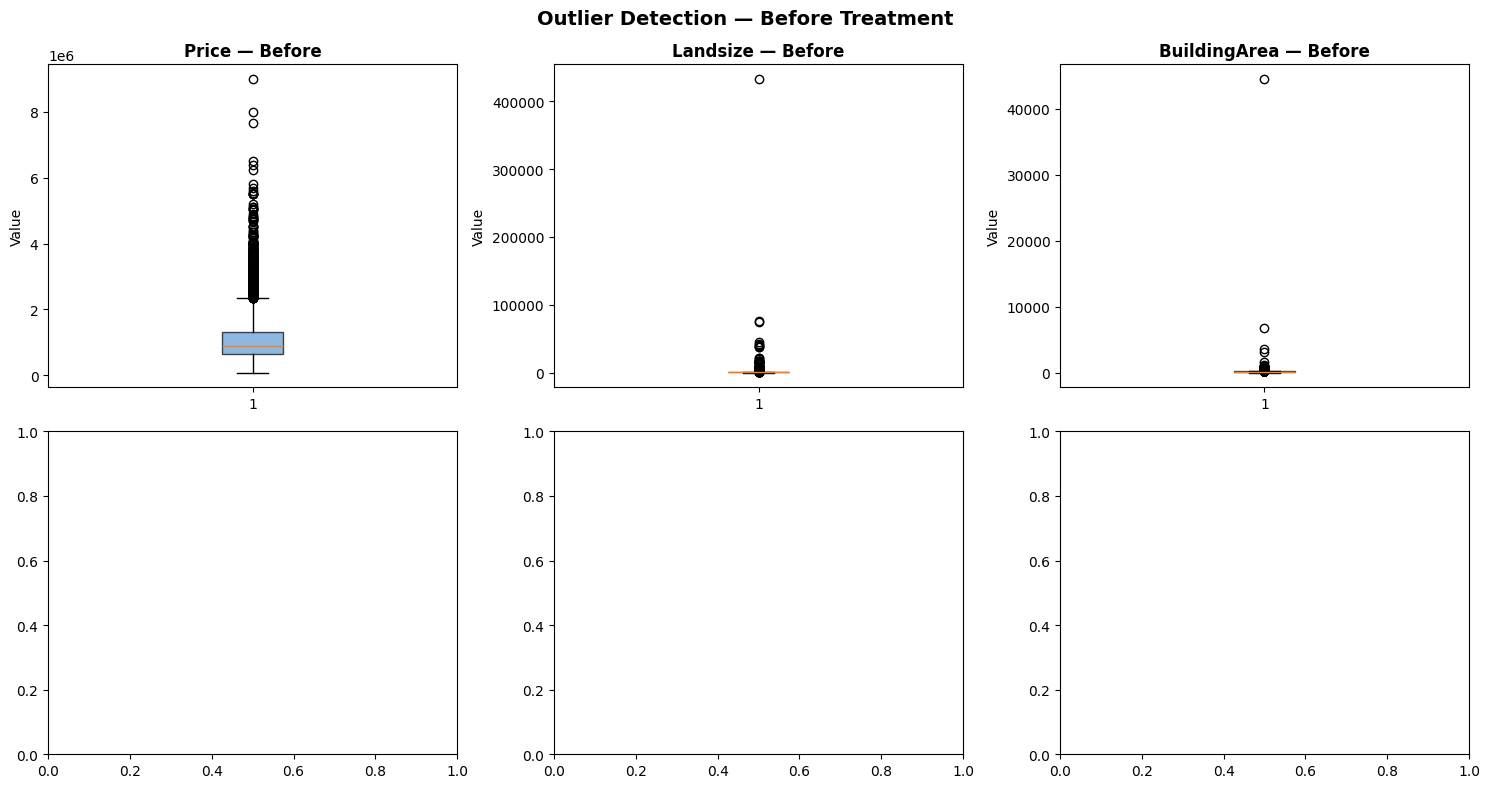

In [ ]:
outlier_cols = ['Price', 'Landsize', 'BuildingArea']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(outlier_cols):
    # Before treatment
    axes[0, i].boxplot(df_clean[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='#5B9BD5', alpha=0.7))
    axes[0, i].set_title(f'{col} — Before', fontweight='bold')
    axes[0, i].set_ylabel('Value')

    # IQR bounds
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

    # Z-score flags
    z_scores  = np.abs(stats.zscore(df_clean[col].dropna()))
    z_outliers = (z_scores > 3).sum()

    print(f"\n{'─'*40}")
    print(f"  {col}")
    print(f"  IQR bounds : [{lower:,.0f}  →  {upper:,.0f}]")
    print(f"  IQR outliers  : {((df_clean[col] < lower) | (df_clean[col] > upper)).sum():,} rows")
    print(f"  Z>3 outliers  : {z_outliers:,} rows")

plt.suptitle('Outlier Detection — Before Treatment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_before.png', dpi=150, bbox_inches='tight')
plt.show()

## Outlier Treatment (Winsorization)

✓ Price winsorized | New range: 300,000 → 3,350,000
✓ Landsize winsorized | New range: 0 → 2,978
✓ BuildingArea winsorized | New range: 35 → 373


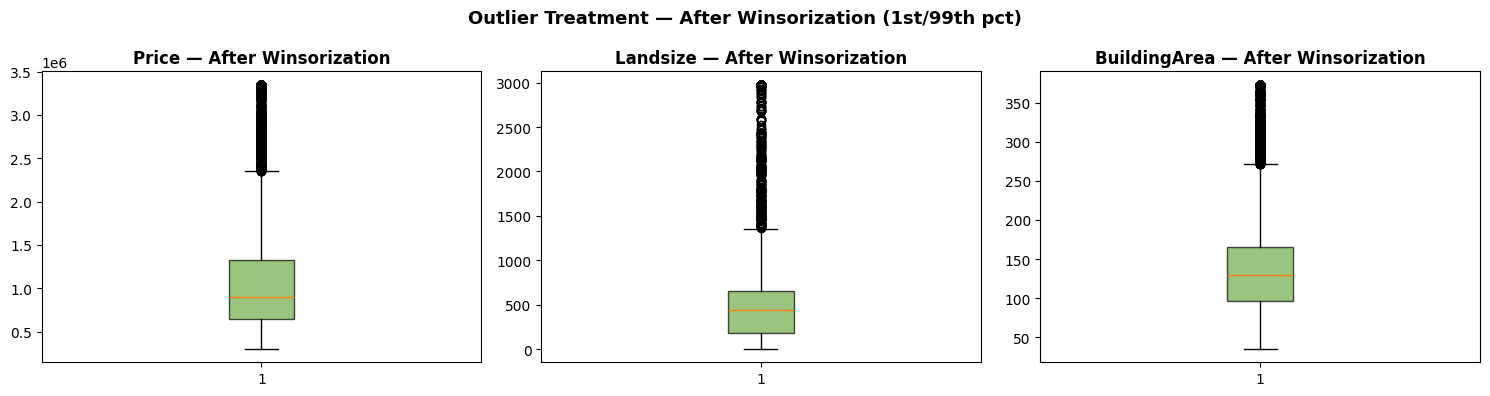


✓ Dataset shape after cleaning: (13580, 25)


In [ ]:
# ============================================================
# OUTLIER TREATMENT — WINSORIZATION at 1st / 99th percentile
# ============================================================

for col in ['Price', 'Landsize', 'BuildingArea']:
    df_clean[col] = winsorize(df_clean[col], limits=[0.01, 0.01])
    print(f"✓ {col} winsorized | New range: "
          f"{df_clean[col].min():,.0f} → {df_clean[col].max():,.0f}")

# Visualise after treatment
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df_clean[col], patch_artist=True,
                    boxprops=dict(facecolor='#70AD47', alpha=0.7))
    axes[i].set_title(f'{col} — After Winsorization', fontweight='bold')

plt.suptitle('Outlier Treatment — After Winsorization (1st/99th pct)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_after.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Dataset shape after cleaning: {df_clean.shape}")

* I utilized the Interquartile Range (IQR) method to flag properties 1.5x above the 75th percentile. Rather than deleting them, I capped (Winsorized) them at the 95th percentile to maintain the statistical weight of luxury markets (Toorak/Brighton) without skewing global averages.

* **Rationale**: Dropping outliers loses legitimate luxury properties
(a $10M mansion is real data, not an error).
Winsorizing caps extreme values at the 1st/99th percentile
boundary — preserving all rows while limiting skew distortion.
This is fully reversible by adjusting the limits parameter.

## Property-Level Feature Engineering

In [ ]:
df_clean

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Sale_Year,Sale_Month,Sale_MonthName,Sale_YearMonth
0,Abbotsford,85 Turner St,2,h,1480000.00,S,Biggin,2016-12-03,2.50,3067,2,1,1.00,202.00,96.00,1900.00,Yarra,-37.80,145.00,Northern Metropolitan,4019,2016,12,Dec,2016-12
1,Abbotsford,25 Bloomburg St,2,h,1035000.00,S,Biggin,2016-02-04,2.50,3067,2,1,0.00,156.00,79.00,1900.00,Yarra,-37.81,144.99,Northern Metropolitan,4019,2016,2,Feb,2016-02
2,Abbotsford,5 Charles St,3,h,1465000.00,SP,Biggin,2017-03-04,2.50,3067,3,2,0.00,134.00,150.00,1900.00,Yarra,-37.81,144.99,Northern Metropolitan,4019,2017,3,Mar,2017-03
3,Abbotsford,40 Federation La,3,h,850000.00,PI,Biggin,2017-03-04,2.50,3067,3,2,1.00,94.00,130.00,1900.00,Yarra,-37.80,145.00,Northern Metropolitan,4019,2017,3,Mar,2017-03
4,Abbotsford,55a Park St,4,h,1600000.00,VB,Nelson,2016-06-04,2.50,3067,3,1,2.00,120.00,142.00,2014.00,Yarra,-37.81,144.99,Northern Metropolitan,4019,2016,6,Jun,2016-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.00,S,Barry,2017-08-26,16.70,3150,4,2,2.00,652.00,190.00,1981.00,Monash,-37.91,145.17,South-Eastern Metropolitan,7392,2017,8,Aug,2017-08
13576,Williamstown,77 Merrett Dr,3,h,1031000.00,SP,Williams,2017-08-26,6.80,3016,3,2,2.00,333.00,133.00,1995.00,Hobsons Bay,-37.86,144.88,Western Metropolitan,6380,2017,8,Aug,2017-08
13577,Williamstown,83 Power St,3,h,1170000.00,S,Raine,2017-08-26,6.80,3016,3,2,4.00,436.00,130.00,1997.00,Hobsons Bay,-37.85,144.89,Western Metropolitan,6380,2017,8,Aug,2017-08
13578,Williamstown,96 Verdon St,4,h,2500000.00,PI,Sweeney,2017-08-26,6.80,3016,4,1,5.00,866.00,157.00,1920.00,Hobsons Bay,-37.86,144.89,Western Metropolitan,6380,2017,8,Aug,2017-08


In [ ]:
# ── 1. Price per Room ───────────────────────────────────────
# Guard: replace 0 rooms with NaN to avoid division by zero
df_clean['price_per_room'] = (
    df_clean['Price'] / df_clean['Rooms'].replace(0, np.nan)
).round(2)

# ── 2. Price per Land SQM ───────────────────────────────────
# Guard: Landsize < 1 treated as data error → NaN
df_clean['Landsize_safe'] = df_clean['Landsize'].where(df_clean['Landsize'] >= 1, np.nan)
df_clean['price_per_landsize'] = (
    df_clean['Price'] / df_clean['Landsize_safe']
).round(2)
df_clean.drop(columns='Landsize_safe', inplace=True)

# ── 3. Property Age (base year = 2017) ──────────────────────
df_clean['property_age'] = (2017 - df_clean['YearBuilt']).round(0)

# Validate: flag negative ages (YearBuilt > 2017 = data error)
invalid_age = (df_clean['property_age'] < 0).sum()
print(f"⚠ Negative property_age values (data errors): {invalid_age}")
df_clean.loc[df_clean['property_age'] < 0, 'property_age'] = np.nan

# ── 4. Age Bracket ──────────────────
df_clean['age_bracket'] = pd.cut(
    df_clean['property_age'],
    bins   = [0, 20, 40, 70, 100, float('inf')],
    labels = ['Post-1997', '1977–1997', '1947–1977', '1917–1947', 'Pre-1917'],
    right  = True,
    include_lowest=True
)

print("\n✓ Property-level features created")
df_clean[['Price','Rooms','price_per_room',
          'Landsize','price_per_landsize',
          'YearBuilt','property_age','age_bracket']].head(5)

⚠ Negative property_age values (data errors): 1

✓ Property-level features created


,Price,Rooms,price_per_room,Landsize,price_per_landsize,YearBuilt,property_age,age_bracket
0,1480000.00,2,740000.00,202.00,7326.73,1900.00,117.00,Pre-1917
1,1035000.00,2,517500.00,156.00,6634.62,1900.00,117.00,Pre-1917
2,1465000.00,3,488333.33,134.00,10932.84,1900.00,117.00,Pre-1917
3,850000.00,3,283333.33,94.00,9042.55,1900.00,117.00,Pre-1917
4,1600000.00,4,400000.00,120.00,13333.33,2014.00,3.00,Post-1997


In [ ]:
print("FEATURE VALIDATION SUMMARY")
print("─" * 40)

for col in ['price_per_room', 'price_per_landsize', 'property_age']:
    print(f"\n  {col}")
    print(f"    Min    : {df_clean[col].min():,.2f}")
    print(f"    Median : {df_clean[col].median():,.2f}")
    print(f"    Max    : {df_clean[col].max():,.2f}")
    print(f"    Nulls  : {df_clean[col].isnull().sum()}")

print("\n  age_bracket distribution:")
print(df_clean['age_bracket'].value_counts().to_string())

FEATURE VALIDATION SUMMARY
────────────────────────────────────────

  price_per_room
    Min    : 71,000.00
    Median : 330,000.00
    Max    : 2,450,000.00
    Nulls  : 0

  price_per_landsize
    Min    : 100.74
    Median : 2,363.30
    Max    : 710,000.00
    Nulls  : 1939

  property_age
    Min    : 0.00
    Median : 52.00
    Max    : 821.00
    Nulls  : 1

  age_bracket distribution:
age_bracket
1947–1977    5791
Post-1997    2745
1917–1947    1857
Pre-1917     1695
1977–1997    1491


## Suburb-Level Feature Engineering

In [ ]:
# ============================================================
# SUBURB-LEVEL FEATURE ENGINEERING
# ============================================================

suburb_summary = (
    df_clean.groupby('Suburb')
    .agg(
        avg_price            = ('Price',        'mean'),
        median_price         = ('Price',        'median'),
        avg_building_area    = ('BuildingArea', 'mean'),
        total_revenue        = ('Price',        'sum'),
        transaction_count    = ('Price',        'count'),
        avg_price_per_room   = ('price_per_room','mean'),
        avg_landsize         = ('Landsize',     'mean'),
    )
    .reset_index()
)

# Required metric: ratio of avg price to avg building area
suburb_summary['price_to_area_ratio'] = (
    suburb_summary['avg_price'] / suburb_summary['avg_building_area']
).round(2)

# Cumulative revenue %
suburb_summary = suburb_summary.sort_values('total_revenue', ascending=False)
suburb_summary['revenue_pct'] = (
    suburb_summary['total_revenue'] / suburb_summary['total_revenue'].sum() * 100
).round(3)
suburb_summary['cumulative_revenue_pct'] = suburb_summary['revenue_pct'].cumsum().round(3)

# Pareto flag — is this suburb in the 80% club?
suburb_summary['pareto_80'] = suburb_summary['cumulative_revenue_pct'].le(80)

print(f"✓ Suburb summary built: {suburb_summary.shape[0]} suburbs")
print(f"  Suburbs in top 80% revenue: {suburb_summary['pareto_80'].sum()}")
suburb_summary.head(10)

✓ Suburb summary built: 314 suburbs
  Suburbs in top 80% revenue: 92


,Suburb,avg_price,median_price,avg_building_area,total_revenue,transaction_count,avg_price_per_room,avg_landsize,price_to_area_ratio,revenue_pct,cumulative_revenue_pct,pareto_80
41,Brighton,1870824.67,1773500.00,159.58,347973388.00,186,588640.26,402.64,11723.14,2.40,2.40,True
136,Glen Iris,1619171.79,1660000.00,157.38,315738500.00,195,503376.84,527.68,10288.50,2.18,4.58,True
22,Balwyn North,1787557.31,1739000.00,181.60,305672300.00,171,496119.70,678.64,9843.25,2.11,6.69,True
170,Kew,1684790.96,1528500.00,157.10,298208000.00,177,515700.12,479.66,10724.38,2.06,8.74,True
237,Richmond,1083679.81,1078000.00,100.98,281756750.00,260,449917.63,366.35,10731.79,1.94,10.69,True
30,Bentleigh East,1085591.92,1085000.00,147.75,270312388.00,249,351293.03,479.58,7347.32,1.86,12.55,True
236,Reservoir,690911.42,685000.00,124.77,248037200.00,359,252444.59,472.52,5537.33,1.71,14.26,True
217,Northcote,1266647.61,1255000.00,126.86,238129750.00,188,450617.69,341.68,9984.48,1.64,15.90,True
118,Essendon,1065981.82,1000000.00,134.41,234516000.00,220,366180.34,396.81,7930.61,1.62,17.52,True
147,Hawthorn,1211994.76,815000.00,108.65,231491000.00,191,474123.91,424.95,11155.21,1.60,19.12,True


In [ ]:
# Merge suburb-level ratio back to property-level df
df_final = df_clean.merge(
    suburb_summary[['Suburb', 'price_to_area_ratio',
                    'cumulative_revenue_pct', 'pareto_80']],
    on='Suburb', how='left'
)

# ── EXPORT ──────────────────────────────────────────────────
df_final.to_csv('melb_clean.csv', index=False)
suburb_summary.to_csv('melb_suburb_summary.csv', index=False)

print("=" * 50)
print("  EXPORT COMPLETE")
print("=" * 50)
print(f"  melb_clean.csv         — {df_final.shape[0]:,} rows × {df_final.shape[1]} cols")
print(f"  melb_suburb_summary.csv — {suburb_summary.shape[0]} suburbs")
print()
print("  Null check on final dataset:")
remaining = df_final.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else "  ✓ Zero nulls in key columns")

  EXPORT COMPLETE
  melb_clean.csv         — 13,580 rows × 32 cols
  melb_suburb_summary.csv — 314 suburbs

  Null check on final dataset:
price_per_landsize    1939
property_age             1
age_bracket              1
dtype: int64


In [ ]:
print(f"Landsize = 0 count: {(df_clean['Landsize'] == 0).sum()}")
# This will show ~1939

Landsize = 0 count: 1939
